### A house price prediction model based on gradient descent taking in account only one variable that is (area)
#### The goal of this project was learn to implement linear gradient model in python by calculating loss function and updating variable 


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Housing.csv")

In [3]:
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
datas = df[['price', 'area']]

In [11]:
datas.describe()

,price,area
count,5.450000e+02,545.000000
mean,4.766729e+06,5150.541284
std,1.870440e+06,2170.141023
min,1.750000e+06,1650.000000
25%,3.430000e+06,3600.000000
50%,4.340000e+06,4600.000000
75%,5.740000e+06,6360.000000
max,1.330000e+07,16200.000000


In [7]:
to_train = datas[:400]

In [8]:
to_train

,price,area
0,13300000,7420
1,12250000,8960
2,12250000,9960
3,12215000,7500
4,11410000,7420
...,...,...
395,3500000,3600
396,3500000,3640
397,3500000,5900
398,3500000,3120


#### Assigning the price of the house to the Y-variable divided by 1 million for a better view in the graph
#### Assigning the area of the house to the X-variable divided by 1000 for a better view in the graph

In [21]:
# Y = mx+C + noise
# Y := price
# X := area
X = np.array(to_train['area']/1000)
Y = np.array(to_train['price']/1000000)

In [25]:
print(X)

[ 7.42   8.96   9.96   7.5    7.42   7.5    8.58  16.2    8.1    5.75
 13.2    6.     6.55   3.5    7.8    6.     6.6    8.5    4.6    6.42
  4.32   7.155  8.05   4.56   8.8    6.54   6.     8.875  7.95   5.5
  7.475  7.     4.88   5.96   6.84   7.     7.482  9.     6.     6.
  6.55   6.36   6.48   6.     6.     6.     6.     6.6    4.3    7.44
  7.44   6.325  6.     5.15   6.     6.    11.44   9.     7.68   6.
  6.     8.88   6.24   6.36  11.175  8.88  13.2    7.7    6.    12.09
  4.     6.     5.02   6.6    4.04   4.26   6.42   6.5    5.7    6.
  6.     4.    10.5    6.     3.76   8.25   6.67   3.96   7.41   8.58
  5.     6.75   4.8    7.2    6.     4.1    9.     6.4    6.6    6.
  6.6    5.5    5.5    6.35   5.5    4.5    5.45   6.42   3.24   6.615
  6.6    8.372  4.3    9.62   6.8    8.     6.9    3.7    6.42   7.02
  6.54   7.231  6.254  7.32   6.525 15.6    7.16   6.5    5.5   11.46
  4.8    5.828  5.2    4.8    7.     6.     5.4    4.64   5.     6.36
  5.8    6.66  10.5    4.8  

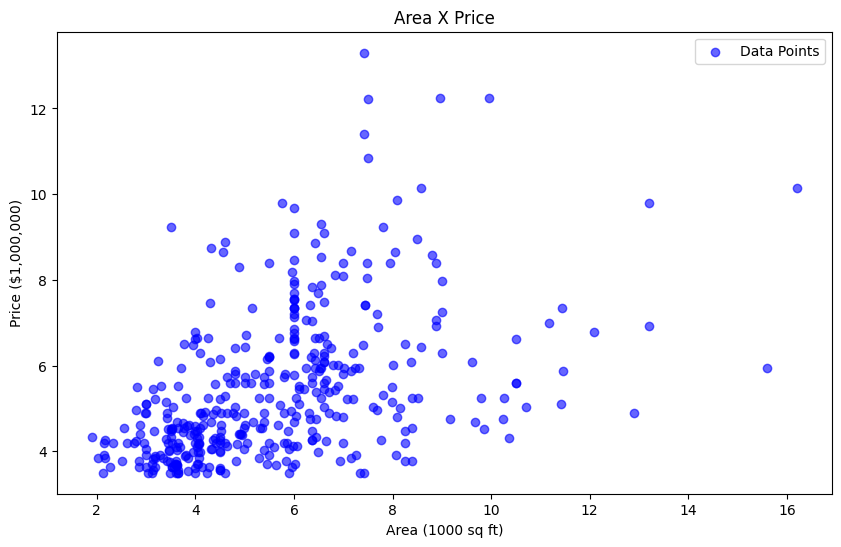

In [26]:
plt.figure(figsize=(10,6))
plt.scatter(X,Y,color="blue", label="Data Points", alpha=0.6)
plt.xlabel("Area (1000 sq ft)")
plt.ylabel("Price ($1,000,000)")
plt.title("Area X Price")
plt.legend()
plt.show()

Assigning variables to calculate loss

In [61]:
lost_history=[]
# Y = mx +c
m,c = 4,3
learning_rate = 0.02
iterations = 2000

### Gradient Descent and Loss Function implementation

In [59]:
for i in range(iterations):
    Ypred = m*X + c
    error = Ypred - Y
    grad_m = 2/len(X) * np.sum(X * error)
    grad_c = 2/len(X) * np.sum(error)
    m = m - learning_rate * grad_m
    c = c - learning_rate * grad_c

    loss = np.mean(np.sum(error ** 2))
    lost_history.append(loss)

In [56]:
print(lost_history)

[np.float64(185863.6703187836), np.float64(44157.55757531854), np.float64(11058.25203467631), np.float64(3326.733653256744), np.float64(1520.487825633948), np.float64(1098.2384003015854), np.float64(999.2589197281394), np.float64(975.7906682289222), np.float64(969.9634846310025), np.float64(968.2603370584847), np.float64(967.5239551154061), np.float64(967.0168451413549), np.float64(966.5667120426292), np.float64(966.1332770736676), np.float64(965.7070975024213), np.float64(965.2859334580996), np.float64(964.8692278252396), np.float64(964.4568168840042), np.float64(964.0486291450579), np.float64(963.6446150015569), np.float64(963.2447302941738), np.float64(962.8489324688684), np.float64(962.4571796760397), np.float64(962.0694305567415), np.float64(961.6856441894183), np.float64(961.3057800741616), np.float64(960.92979812577), np.float64(960.5576586688956), np.float64(960.1893224337111), np.float64(959.8247505517334), np.float64(959.4639045517126), np.float64(959.1067463555707), np.float

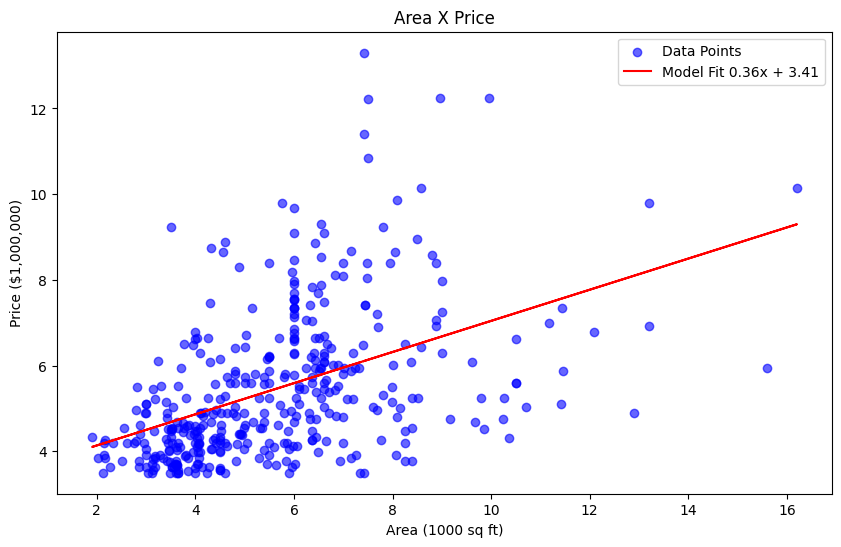

In [60]:
plt.figure(figsize=(10,6))
plt.scatter(X,Y,color="blue", label="Data Points", alpha=0.6)
plt.plot(X, m*X + c, color="red", label=f"Model Fit {m:.2f}x + {c:.2f}")
plt.xlabel("Area (1000 sq ft)")
plt.ylabel("Price ($1,000,000)")
plt.title("Area X Price")
plt.legend()
plt.show()

In [65]:
print(datas['area'][520]," ", datas['price'][520])

7700   2450000


In [66]:
print((m*7.7+c)*1000000)

33800000.0
